![alt text](images/subgraph.png)

In [2]:
%run init_env.py

Added to Python path: C:\Users\akhawaja\git\cs5305\genai-langchain
Environment initialization completed successfully.


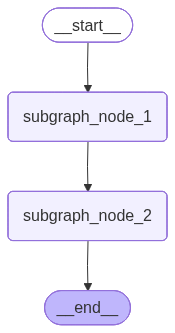

In [3]:
from typing_extensions import TypedDict
from langgraph.graph.state import StateGraph, START
from IPython.display import Image, display

# Define subgraph
class SubgraphState(TypedDict):
    # note that none of these keys are shared with the parent graph state
    bar: str
    baz: str

def subgraph_node_1(state: SubgraphState):
    return {"baz": "baz"}

def subgraph_node_2(state: SubgraphState):
    return {"bar": state["bar"] + state["baz"]}

subgraph_builder = StateGraph(SubgraphState)
subgraph_builder.add_node(subgraph_node_1)
subgraph_builder.add_node(subgraph_node_2)
subgraph_builder.add_edge(START, "subgraph_node_1")
subgraph_builder.add_edge("subgraph_node_1", "subgraph_node_2")
subgraph = subgraph_builder.compile()

display(Image(subgraph.get_graph().draw_mermaid_png()))

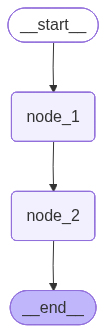

In [5]:
# Define parent graph
class ParentState(TypedDict):
    foo: str

def node_1(state: ParentState):
    return {"foo": "hi! " + state["foo"]}

def node_2(state: ParentState):
    # Transform the state to the subgraph state
    response = subgraph.invoke({"bar": state["foo"]})
    # Transform response back to the parent state
    return {"foo": response["bar"]}


builder = StateGraph(ParentState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
for namespace, chunk in graph.stream({"foo": "foo"}, subgraphs=True, version="v2"):
    print(namespace, chunk)

() {'node_1': {'foo': 'hi! foo'}}
('node_2:295c2699-fd7c-4991-7ff0-1309688f3b72',) {'subgraph_node_1': {'baz': 'baz'}}
('node_2:295c2699-fd7c-4991-7ff0-1309688f3b72',) {'subgraph_node_2': {'bar': 'hi! foobaz'}}
() {'node_2': {'foo': 'hi! foobaz'}}
